In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Internship-Krish-B 09(IT)/student_performance.csv")

In [5]:
df.shape

(10000, 8)

In [10]:
df.head(5)

,Gender,Hours Studied,Previous Scores,Extracurricular Activities,Tuition,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,Female,7,82,Yes,Yes,8,1,82
1,Female,4,51,No,Yes,4,7,37
2,Male,8,52,Yes,Yes,5,0,50
3,Female,5,75,No,Yes,4,1,68
4,Female,7,78,No,Yes,4,6,79


In [9]:
df.tail(5)

,Gender,Hours Studied,Previous Scores,Extracurricular Activities,Tuition,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,Female,1,40,No,No,8,1,17
9996,Female,7,54,Yes,No,5,3,46
9997,Male,6,42,Yes,No,6,4,29
9998,Male,9,45,Yes,Yes,7,9,48
9999,Female,7,53,No,Yes,5,4,50


In [12]:
df.dtypes


,0
Gender,object
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,object
Tuition,object
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,int64


In [13]:

df.describe()


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,68.990000,6.531100,4.588200,58.514800
std,2.589309,17.088051,1.692962,2.866573,19.045494
min,1.000000,40.000000,4.000000,0.000000,13.000000
25%,3.000000,54.000000,5.000000,2.000000,44.000000
50%,5.000000,69.000000,7.000000,5.000000,58.000000
75%,7.000000,84.000000,8.000000,7.000000,74.000000
max,9.000000,98.000000,9.000000,9.000000,100.000000


In [14]:

df.isnull().sum()


,0
Gender,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Tuition,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [15]:

df.duplicated().sum()

np.int64(26)

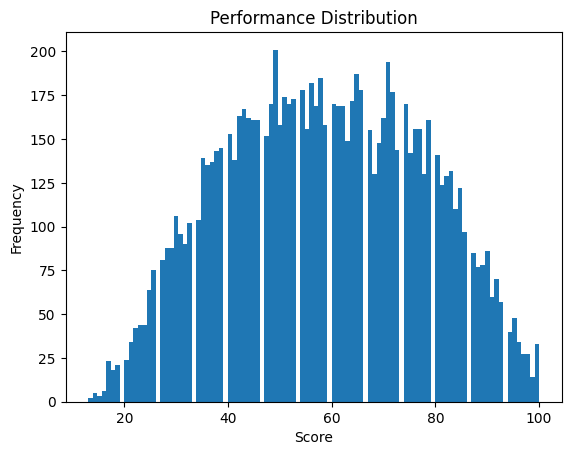

In [19]:
plt.hist(df['Performance Index'], bins=100)
plt.title("Performance Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

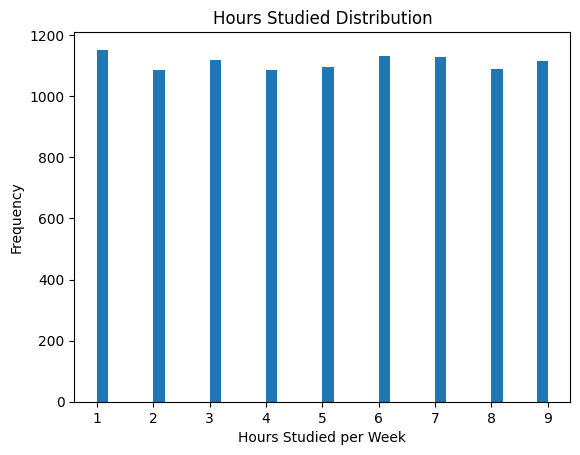

In [23]:
plt.hist(df['Hours Studied'], bins=40)
plt.title("Hours Studied Distribution")
plt.xlabel("Hours Studied per Week")
plt.ylabel("Frequency")
plt.show()

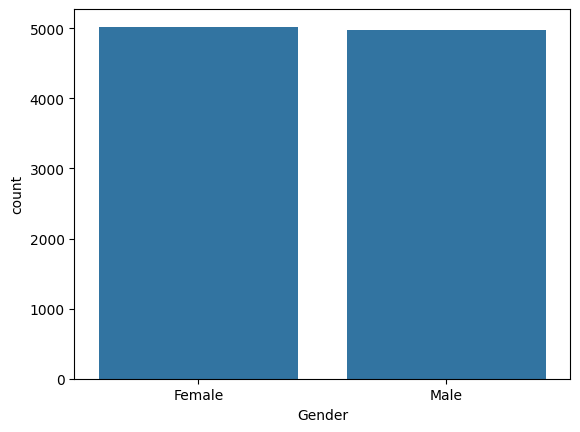

In [24]:
sns.countplot(x='Gender', data=df)
plt.show()

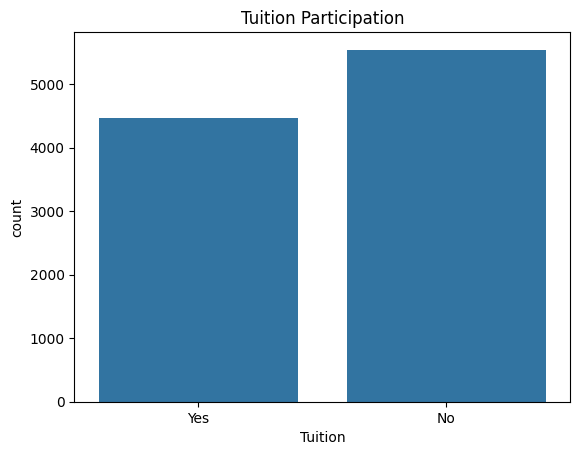

In [27]:
sns.countplot(x='Tuition',data=df)
plt.title("Tuition Participation")
plt.show()

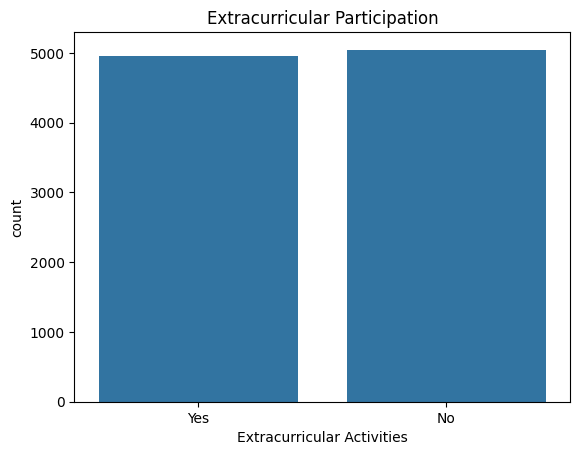

In [28]:
sns.countplot(x='Extracurricular Activities', data=df)
plt.title("Extracurricular Participation")
plt.show()

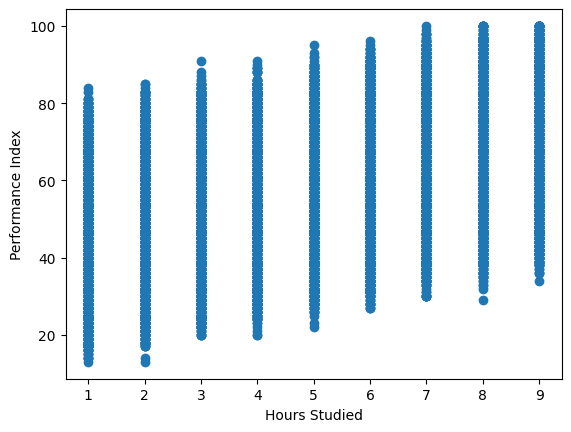

In [29]:
plt.scatter(df['Hours Studied'], df['Performance Index'])
plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")
plt.show()

<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

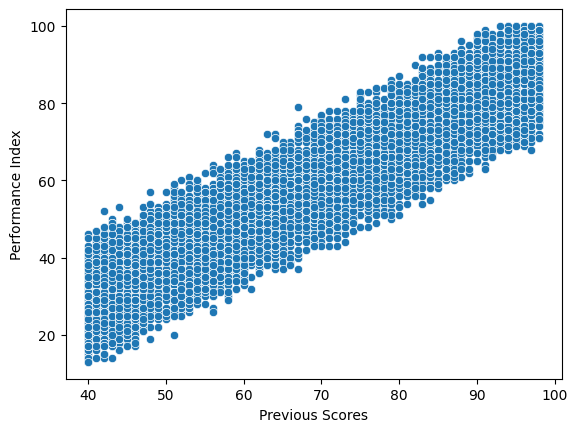

In [30]:
sns.scatterplot(x='Previous Scores', y='Performance Index', data=df)

<Axes: xlabel='Sleep Hours', ylabel='Performance Index'>

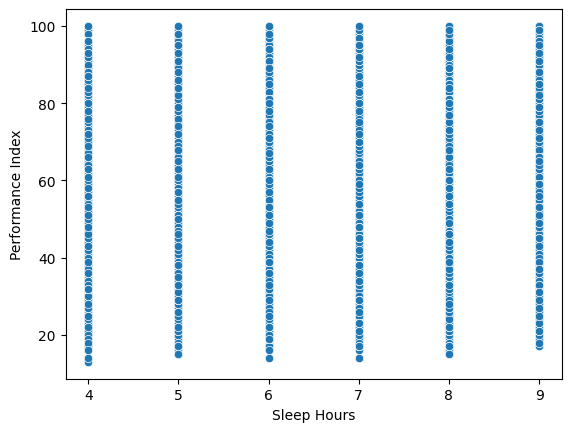

In [31]:
sns.scatterplot(x='Sleep Hours', y='Performance Index', data=df)

<Axes: xlabel='Gender'>

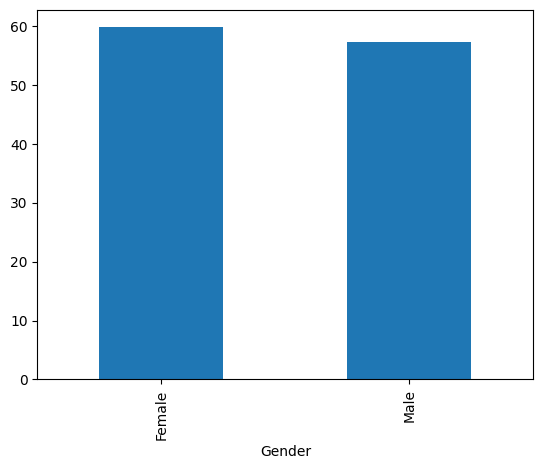

In [32]:
df.groupby('Gender')['Performance Index'].mean().plot(kind='bar')

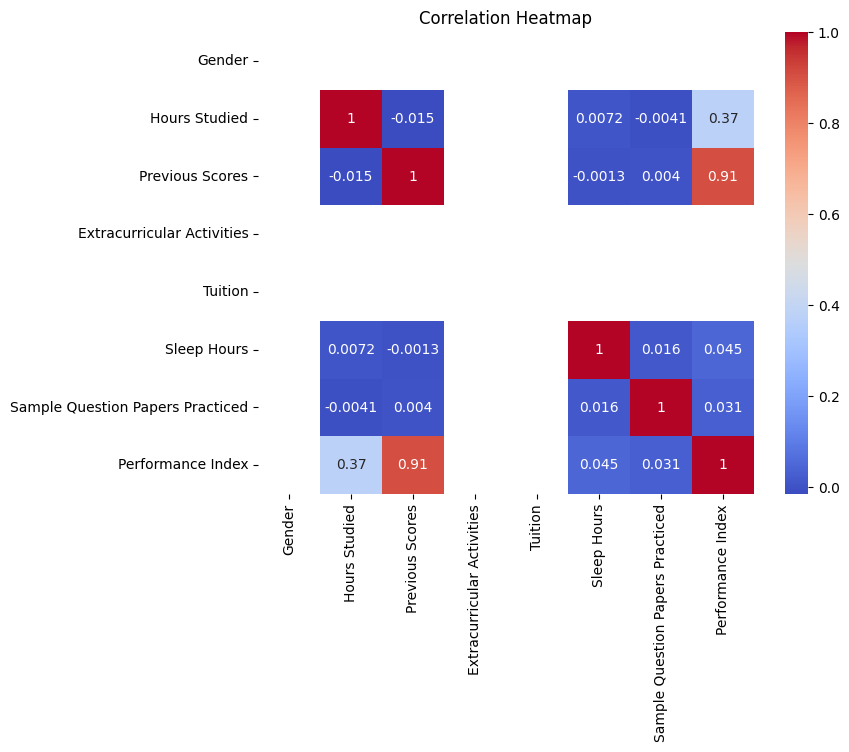

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [60]:
df_encoded = df.copy()
df_encoded['Gender'] = df_encoded['Gender'].map({'Female': 1, 'Male': 0})
df_encoded['Tuition'] = df_encoded['Tuition'].map({'Yes': 1, 'No': 0})
df_encoded['Extracurricular Activities'] = df_encoded['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# Plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap — All Features', fontsize=14)
plt.tight_layout()
plt.show()

corr = df_encoded.corr()['Performance Index'].drop('Performance Index').sort_values(ascending=False)
print('\n--- Correlation with Performance Index ---')
print(corr)

Encoding done. Preview:


,Gender,Hours Studied,Previous Scores,Extracurricular Activities,Tuition,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,NaN,7,82,NaN,NaN,8,1,82
1,NaN,4,51,NaN,NaN,4,7,37
2,NaN,8,52,NaN,NaN,5,0,50
3,NaN,5,75,NaN,NaN,4,1,68
4,NaN,7,78,NaN,NaN,4,6,79


In [40]:
X = df.drop(columns=['Performance Index'])
y = df['Performance Index']

print(f'Features shape (X): {X.shape}')
print(f'Target shape   (y): {y.shape}')
print(f'\nFeature columns: {list(X.columns)}')

Features shape (X): (10000, 7)
Target shape   (y): (10000,)

Feature columns: ['Gender', 'Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Tuition', 'Sleep Hours', 'Sample Question Papers Practiced']


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  | y_test : {y_test.shape}')

X_train: (8000, 7) | y_train: (8000,)
X_test : (2000, 7)  | y_test : (2000,)


In [44]:
df = pd.read_csv('/content/drive/MyDrive/Internship-Krish-B 09(IT)/student_performance.csv')
df['Gender'] = df['Gender'].map({'Female': 1, 'Male': 0})
df['Tuition'] = df['Tuition'].map({'Yes': 1, 'No': 0})
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
X = df.drop(columns=['Performance Index'])
y = df['Performance Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


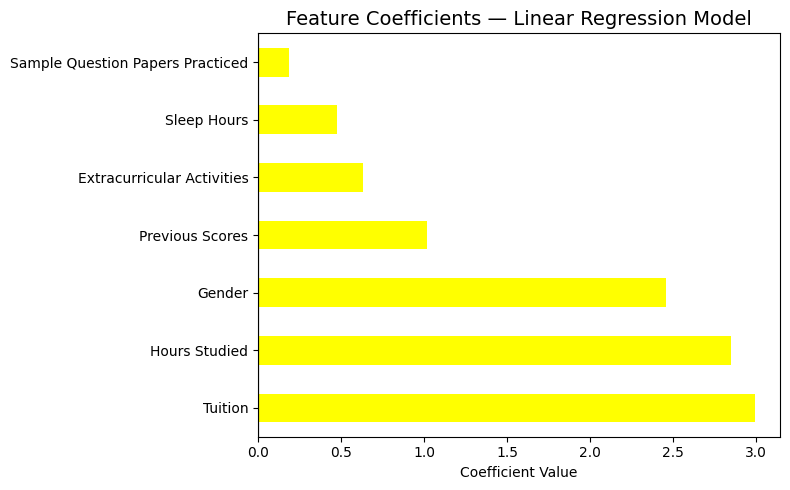

In [46]:
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
colors = ['Yellow' if c > 0 else 'red' for c in coefficients.values]
plt.figure(figsize=(8, 5))
coefficients.plot(kind='barh', color=colors)
plt.title('Feature Coefficients — Linear Regression Model', fontsize=14)
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [47]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual'    : y_test.values[:10],
    'Predicted' : y_pred[:10].round(1),
    'Difference': (y_test.values[:10] - y_pred[:10]).round(1)
})

print('--- First 10: Actual vs Predicted ---')
print(comparison)

--- First 10: Actual vs Predicted ---
   Actual  Predicted  Difference
0      64       64.2        -0.2
1      52       53.7        -1.7
2      47       49.4        -2.4
3      61       59.7         1.3
4      42       41.9         0.1
5      90       91.4        -1.4
6      58       57.1         0.9
7      60       59.8         0.2
8      76       76.2        -0.2
9      67       66.3         0.7


In [48]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'RMSE     : {rmse:.2f}')
print(f'R² Score : {r2:.4f}')

RMSE     : 2.11
R² Score : 0.9875


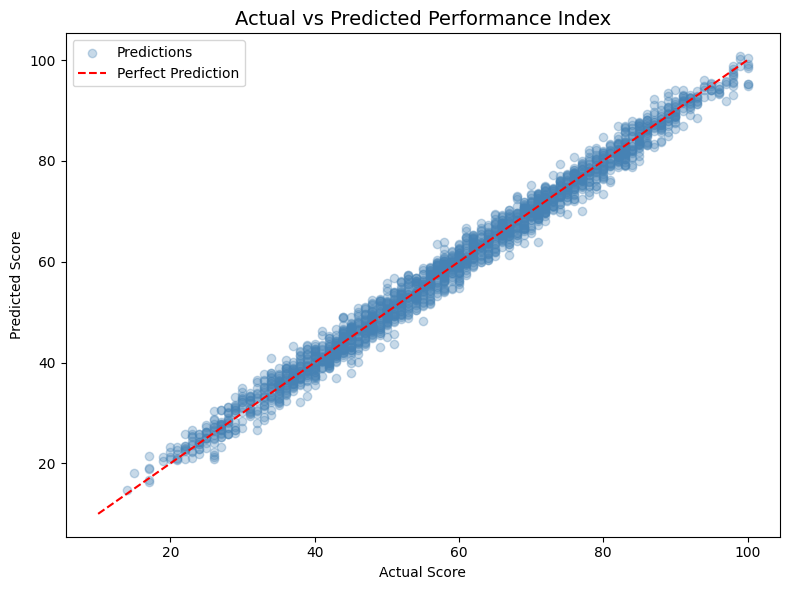

In [49]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', label='Predictions')
plt.plot([10, 100], [10, 100], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs Predicted Performance Index', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

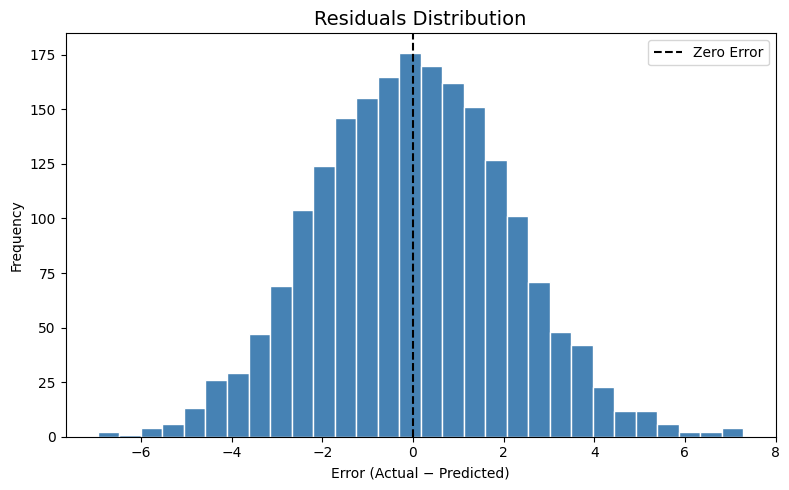

In [51]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='black', linestyle='--', label='Zero Error')
plt.title('Residuals Distribution', fontsize=14)
plt.xlabel('Error (Actual − Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
def predict_score(gender, hours_studied, previous_scores, extracurricular, tuition, sleep_hours, sample_papers):
    """
    Predict a student's Performance Index.

    Parameters:
    - gender            : 'Female' or 'Male'
    - hours_studied     : int (1–9)
    - previous_scores   : int (40–99)
    - extracurricular   : 'Yes' or 'No'
    - tuition           : 'Yes' or 'No'
    - sleep_hours       : int (4–9)
    - sample_papers     : int (0–9)
    """
    g = 1 if gender.lower() == 'female' else 0
    e = 1 if extracurricular.lower() == 'yes' else 0
    t = 1 if tuition.lower() == 'yes' else 0

    student = pd.DataFrame(
        [[g, hours_studied, previous_scores, e, t, sleep_hours, sample_papers]],
        columns=X.columns
    )
    score = model.predict(student)[0]
    print(f'Predicted Performance Index: {round(score, 1)} / 100')
    return round(score, 1)
print(' predict_score() function is ready!')

 predict_score() function is ready!


In [53]:
print('=== Student A — High performer ===')
predict_score('Female', 8, 85, 'Yes', 'Yes', 7, 5)

print('\n=== Student B — Low performer ===')
predict_score('Male', 2, 50, 'No', 'No', 5, 1)

print('\n=== Student C — Average student ===')
predict_score('Female', 5, 70, 'Yes', 'No', 6, 3)

=== Student A — High performer ===
Predicted Performance Index: 86.9 / 100

=== Student B — Low performer ===
Predicted Performance Index: 26.4 / 100

=== Student C — Average student ===
Predicted Performance Index: 59.2 / 100


np.float64(59.2)

In [54]:
print('=== Tuition: Yes vs No (all else equal) ===')
predict_score('Female', 5, 70, 'Yes', 'Yes', 6, 3)
predict_score('Female', 5, 70, 'Yes', 'No',  6, 3)

print('\n=== Gender: Female vs Male (all else equal) ===')
predict_score('Female', 5, 70, 'Yes', 'No', 6, 3)
predict_score('Male',   5, 70, 'Yes', 'No', 6, 3)

print('\n=== Hours Studied: 3 hrs vs 8 hrs ===')
predict_score('Male', 3, 70, 'No', 'No', 6, 3)
predict_score('Male', 8, 70, 'No', 'No', 6, 3)

=== Tuition: Yes vs No (all else equal) ===
Predicted Performance Index: 62.2 / 100
Predicted Performance Index: 59.2 / 100

=== Gender: Female vs Male (all else equal) ===
Predicted Performance Index: 59.2 / 100
Predicted Performance Index: 56.8 / 100

=== Hours Studied: 3 hrs vs 8 hrs ===
Predicted Performance Index: 50.4 / 100
Predicted Performance Index: 64.7 / 100


np.float64(64.7)

In [57]:
results = pd.DataFrame({
    'Actual Score'   : y_test.values,
    'Predicted Score': y_pred.round(1),
    'Difference'     : (y_test.values - y_pred).round(1)
})
results.to_csv('student_predictions.csv', index=False)

print(' student_predictions.csv saved!')
display(results.head(10))

 student_predictions.csv saved!


,Actual Score,Predicted Score,Difference
0,64,64.2,-0.2
1,52,53.7,-1.7
2,47,49.4,-2.4
3,61,59.7,1.3
4,42,41.9,0.1
5,90,91.4,-1.4
6,58,57.1,0.9
7,60,59.8,0.2
8,76,76.2,-0.2
9,67,66.3,0.7


In [56]:
within_5 = (abs(results['Difference']) <= 5).mean() * 100
print(f'✅ {within_5:.1f}% of predictions are within ±5 marks of the actual score')

✅ 98.2% of predictions are within ±5 marks of the actual score


In [ ]:
from google.colab import files
files.download("salary_prediction.pkl")
